In [2]:
import pandas as pd 
import numpy as np

pd.set_option('display.max_columns', None)

bank_df = pd.read_csv('bank-additional.csv')


# Renombrar columnas manualmente
bank_df.columns = [
    'index', 'age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
    'contact', 'duration', 'campaign', 'pdays', 'previous', 'poutcome',
    'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m',
    'nr.employed', 'y', 'date', 'latitude', 'longitude', 'id_'
]
bank_df.drop(columns='index', inplace=True)

print(bank_df.head())

    age        job  marital    education  default  housing  loan    contact  \
0   NaN  housemaid  MARRIED     basic.4y      0.0      0.0   0.0  telephone   
1  57.0   services  MARRIED  high.school      NaN      0.0   0.0  telephone   
2  37.0   services  MARRIED  high.school      0.0      1.0   0.0  telephone   
3  40.0     admin.  MARRIED     basic.6y      0.0      0.0   0.0  telephone   
4  56.0   services  MARRIED  high.school      0.0      0.0   1.0  telephone   

   duration  campaign  pdays  previous     poutcome  emp.var.rate  \
0       261         1    999         0  NONEXISTENT           1.1   
1       149         1    999         0  NONEXISTENT           1.1   
2       226         1    999         0  NONEXISTENT           1.1   
3       151         1    999         0  NONEXISTENT           1.1   
4       307         1    999         0  NONEXISTENT           1.1   

  cons.price.idx cons.conf.idx euribor3m nr.employed   y                date  \
0         93,994         -36,4

In [3]:
import pandas as pd 
import numpy as np

pd.set_option('display.max_columns', None)

customer_data = pd.ExcelFile('customer-details.xlsx')

customer_df = pd.concat([customer_data.parse(sheet) for sheet in customer_data.sheet_names], ignore_index=True)

# nos quedamos con las columnas que no empiezan por 'Unnamed'
customer_df = customer_df.loc[:, ~customer_df.columns.str.startswith('Unnamed')]

# Convertir la fecha 'Dt_Customer' a tipo datetime si no lo está
if customer_df['Dt_Customer'].dtype != 'datetime64[ns]':
    customer_df['Dt_Customer'] = pd.to_datetime(customer_df['Dt_Customer'], errors='coerce')

# Verificar resultado
print("Columnas cargadas:", customer_df.columns.tolist())
print("\nPrimeras filas:")
print(customer_df.head())

# Info general
print("\nInfo:")
print(customer_df.info())


Columnas cargadas: ['Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'NumWebVisitsMonth', 'ID']

Primeras filas:
   Income  Kidhome  Teenhome Dt_Customer  NumWebVisitsMonth  \
0  161770        1         0  2012-04-04                 29   
1   85477        1         1  2012-12-30                  7   
2  147233        1         1  2012-02-02                  5   
3  121393        1         2  2012-12-21                 29   
4   63164        1         2  2012-06-20                 20   

                                     ID  
0  089b39d8-e4d0-461b-87d4-814d71e0e079  
1  e9d37224-cb6f-4942-98d7-46672963d097  
2  3f9f49b5-e410-4948-bf6e-f9244f04918b  
3  9991fafb-4447-451a-8be2-b0df6098d13e  
4  eca60b76-70b6-4077-80ba-bc52e8ebb0eb  

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43170 entries, 0 to 43169
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Income             43170 no

In [4]:
# Unión de los DataFrames por ID
merged_df = pd.merge(
    bank_df,          # Datos de campañas
    customer_df,      # Datos de clientes
    how='left',      # Queremos mantener todos los registros de bank_df
    left_on='id_',    # Clave en bank_df
    right_on='ID'     # Clave en customer_df
)

# Verificar el tamaño del resultado
print(f"Registros combinados: {merged_df.shape[0]} filas, {merged_df.shape[1]} columnas")

# Ver primeras filas
print(merged_df.head())

# Verificar valores nulos tras la unión
print("\nValores nulos por columna:\n", merged_df.isnull().sum())

merged_df.head()

Registros combinados: 43000 filas, 29 columnas
    age        job  marital    education  default  housing  loan    contact  \
0   NaN  housemaid  MARRIED     basic.4y      0.0      0.0   0.0  telephone   
1  57.0   services  MARRIED  high.school      NaN      0.0   0.0  telephone   
2  37.0   services  MARRIED  high.school      0.0      1.0   0.0  telephone   
3  40.0     admin.  MARRIED     basic.6y      0.0      0.0   0.0  telephone   
4  56.0   services  MARRIED  high.school      0.0      0.0   1.0  telephone   

   duration  campaign  pdays  previous     poutcome  emp.var.rate  \
0       261         1    999         0  NONEXISTENT           1.1   
1       149         1    999         0  NONEXISTENT           1.1   
2       226         1    999         0  NONEXISTENT           1.1   
3       151         1    999         0  NONEXISTENT           1.1   
4       307         1    999         0  NONEXISTENT           1.1   

  cons.price.idx cons.conf.idx euribor3m nr.employed   y       

,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID
0,NaN,housemaid,MARRIED,basic.4y,0.0,0.0,0.0,telephone,261,1,999,0,NONEXISTENT,1.1,"93,994","-36,4","4,857",5191,no,2-agosto-2019,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079,161770,1,0,2012-04-04,29,089b39d8-e4d0-461b-87d4-814d71e0e079
1,57.0,services,MARRIED,high.school,NaN,0.0,0.0,telephone,149,1,999,0,NONEXISTENT,1.1,"93,994","-36,4",NaN,5191,no,14-septiembre-2016,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097,85477,1,1,2012-12-30,7,e9d37224-cb6f-4942-98d7-46672963d097
2,37.0,services,MARRIED,high.school,0.0,1.0,0.0,telephone,226,1,999,0,NONEXISTENT,1.1,"93,994","-36,4","4,857",5191,no,15-febrero-2019,34.939,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b,147233,1,1,2012-02-02,5,3f9f49b5-e410-4948-bf6e-f9244f04918b
3,40.0,admin.,MARRIED,basic.6y,0.0,0.0,0.0,telephone,151,1,999,0,NONEXISTENT,1.1,"93,994","-36,4",NaN,5191,no,29-noviembre-2015,49.041,-70.308,9991fafb-4447-451a-8be2-b0df6098d13e,121393,1,2,2012-12-21,29,9991fafb-4447-451a-8be2-b0df6098d13e
4,56.0,services,MARRIED,high.school,0.0,0.0,1.0,telephone,307,1,999,0,NONEXISTENT,1.1,"93,994","-36,4",NaN,5191,no,29-enero-2017,38.033,-104.463,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,63164,1,2,2012-06-20,20,eca60b76-70b6-4077-80ba-bc52e8ebb0eb


In [5]:
# ¿Hay filas duplicadas?
duplicados = merged_df.duplicated().sum()
print(f"Filas duplicadas totales: {duplicados}")

# ¿Hay duplicados por cliente (id_)?
duplicados_id = merged_df['id_'].duplicated().sum()
print(f"Duplicados por ID de cliente: {duplicados_id}")

# ¿Cuántos valores nulos hay por columna?
print("Valores nulos por columna:\n")
print(merged_df.isnull().sum())

# ¿Qué porcentaje de valores nulos hay por columna?
print("Porcentaje de valores nulos por columna:\n")
print((merged_df.isnull().mean() * 100).round(2).sort_values(ascending=False))

Filas duplicadas totales: 0
Duplicados por ID de cliente: 0
Valores nulos por columna:

age                  5120
job                   345
marital                85
education            1807
default              8981
housing              1026
loan                 1026
contact                 0
duration                0
campaign                0
pdays                   0
previous                0
poutcome                0
emp.var.rate            0
cons.price.idx        471
cons.conf.idx           0
euribor3m            9256
nr.employed             0
y                       0
date                  248
latitude                0
longitude               0
id_                     0
Income                  0
Kidhome                 0
Teenhome                0
Dt_Customer             0
NumWebVisitsMonth       0
ID                      0
dtype: int64
Porcentaje de valores nulos por columna:

euribor3m            21.53
default              20.89
age                  11.91
education             

In [6]:
#1.2 IMPUTACION DE DATOS A LAS COLUMNAS CON NULOS PARA OBTENER UN MEJOR ANALISIS EDA
# En que baso esta estrategia de imputación:
#    - Convertimos las comas de los decimales a float
#    - Valores nulos numéricos → media ( Suposición: los datos siguen una distribución normal ya que es una base de datos con muchos registros y tenderá a comportarse así)
#    - Variables binarias (default, loan, housing) → -1 para "desconocido"
#    - Categóricas (job, education, marital) → moda (valor más común)

import pandas as pd

# --- Limpieza de columnas con coma decimal ---
columnas_coma_decimal = ['euribor3m', 'cons.price.idx', 'nr.employed']

for col in columnas_coma_decimal:
    # Asegura que son strings y reemplaza coma por punto
    merged_df[col] = merged_df[col].astype(str).str.replace(',', '.')
    # Convierte a numérico (float), forzando NaN si hay error
    merged_df[col] = pd.to_numeric(merged_df[col], errors='coerce')

# --- Imputación de valores numéricos con la media ---
media_cols = ['euribor3m', 'cons.price.idx', 'nr.employed', 'age']

for col in media_cols:
    mean_val = merged_df[col].mean()
    merged_df[col] = merged_df[col].fillna(mean_val)

# --- Imputación de valores binarios con categoría "desconocido" (-1) ---
binarias_con_nulos = ['default', 'loan', 'housing']

for col in binarias_con_nulos:
    merged_df[col] = merged_df[col].fillna(-1).astype(int)

# --- Imputación de categóricas con la moda ---
categ_modas = ['job', 'education', 'marital']

for col in categ_modas:
    moda = merged_df[col].mode()[0]
    merged_df[col] = merged_df[col].fillna(moda)

# --- Revisión final ---
print("Nulos restantes después de limpieza:\n")
print(merged_df.isnull().sum().sort_values(ascending=False))

Nulos restantes después de limpieza:

date                 248
job                    0
marital                0
education              0
age                    0
housing                0
loan                   0
contact                0
duration               0
campaign               0
pdays                  0
previous               0
default                0
poutcome               0
emp.var.rate           0
cons.conf.idx          0
cons.price.idx         0
euribor3m              0
nr.employed            0
y                      0
latitude               0
longitude              0
id_                    0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
NumWebVisitsMonth      0
ID                     0
dtype: int64


In [21]:
# 2. ANALISIS EDA
# 2.1 Análisis Descriptivo de los Datos

# Variables numéricas principales
columnas_numericas = ['age', 'Income', 'duration', 'NumWebVisitsMonth', 'euribor3m', 'nr.employed', 'cons.price.idx']

# Convertimos las variables a numéricas (float o int)
merged_df[columnas_numericas] = merged_df[columnas_numericas].apply(pd.to_numeric, errors='coerce')

# Estadísticas descriptivas básicas
print("Estadísticas descriptivas básicas:\n")
print(
    merged_df[columnas_numericas]
    .describe()
    .T[['mean', '50%', 'std', 'min', 'max']]
    .rename(columns={'50%': 'median'})
)

Estadísticas descriptivas básicas:

                           mean        median           std       min  \
age                   39.977112     39.977112      9.796830    17.000   
Income             93241.200070  93050.500000  50498.316182  5841.000   
duration             257.739279    179.000000    258.666033     0.000   
NumWebVisitsMonth     16.589698     17.000000      9.239205     1.000   
euribor3m              3.616521      4.076000      1.538834     0.634   
nr.employed         5166.852602   5191.000000     72.411125  4963.600   
cons.price.idx        93.574219     93.574219      0.576365    92.201   

                          max  
age                    98.000  
Income             180802.000  
duration             4918.000  
NumWebVisitsMonth      32.000  
euribor3m               5.045  
nr.employed          5228.100  
cons.price.idx         94.767  


In [22]:
#       2. Desviación estándar y rango intercuartílico
iqr_df = merged_df[columnas_numericas].quantile([0.25, 0.75]).T
iqr_df['IQR'] = iqr_df[0.75] - iqr_df[0.25]
iqr_df = iqr_df[['IQR']]

print("\nRango intercuartílico (IQR):\n")
print(iqr_df)


Rango intercuartílico (IQR):

                         IQR
age                   13.000
Income             87134.500
duration             217.000
NumWebVisitsMonth     16.000
euribor3m              3.493
nr.employed          129.000
cons.price.idx         0.919


In [ ]:
#       3. Correlación entre variables numéricas. Instalamos seaborn para visualizar la matriz de correlación
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


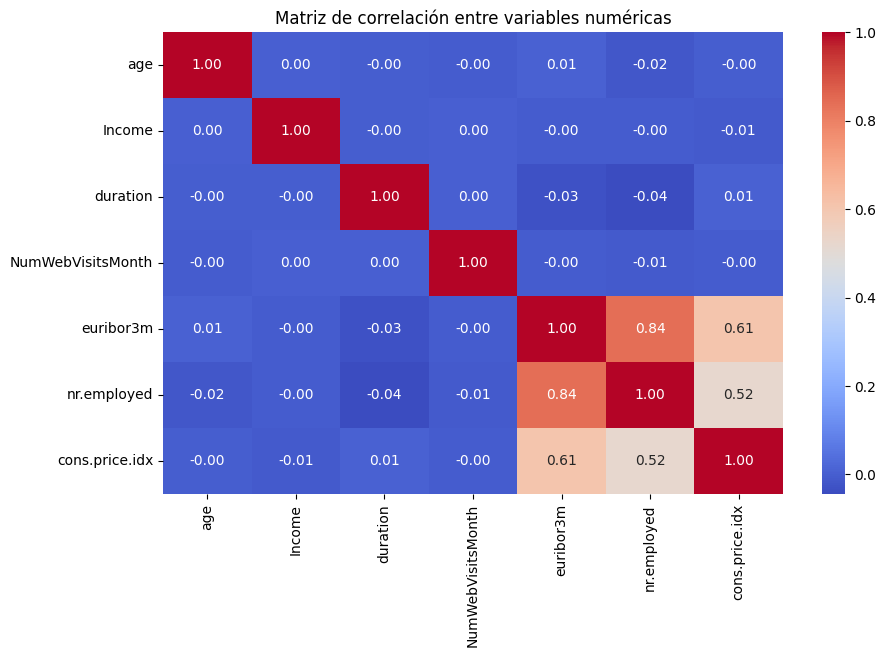

In [ ]:
#                          Correlación entre variables numéricas. Visualizamos la matriz de correlación con seaborn
 
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
cor_matrix = merged_df[columnas_numericas].corr()
sns.heatmap(cor_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación entre variables numéricas')
plt.show()

In [ ]:
# Observaciones clave a destacar:
#   - Variables como duration pueden no estar correlacionadas con otras variables, pero sí con el target.
#   - age y income no suelen estar fuertemente correlacionadas.
#   - euribor3m, nr.employed y cons.price.idx pueden estar correlacionadas entre sí, reflejando el contexto económico.

In [ ]:
# 2.2 EDA: Análisis Univariado

# Vamos a analizar primero variables por separado, para entender su distribución, los valores frecuentes, y posible presencia de anomalías.

# Variables clave: y (target), age, duration, income, job, education, marital, NumWebVisitsMonth.

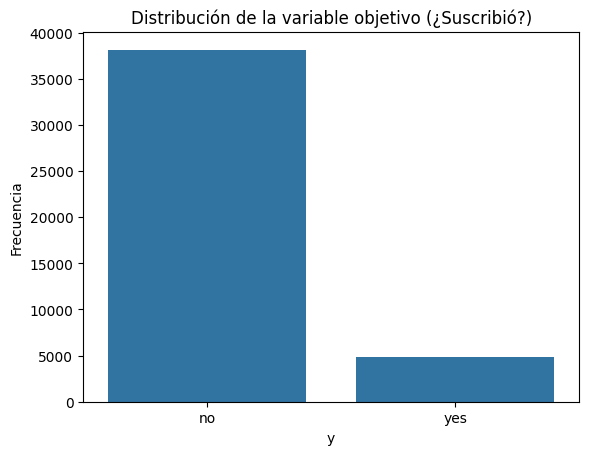


Porcentaje de cada clase:
y
no     88.734884
yes    11.265116
Name: proportion, dtype: float64


In [ ]:
        # 1. Distribución de la variable objetivo y 

import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=merged_df, x='y')
plt.title('Distribución de la variable objetivo (¿Suscribió?)')
plt.xlabel('y')
plt.ylabel('Frecuencia')
plt.show()

print("\nPorcentaje de cada clase:")
print(merged_df['y'].value_counts(normalize=True) * 100)

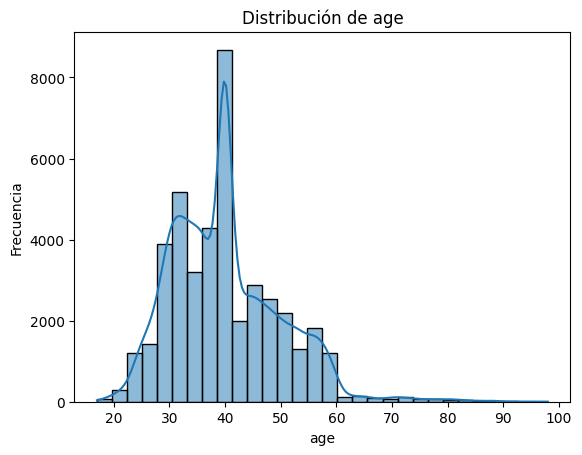


Estadísticas de age:
count    43000.000000
mean        39.977112
std          9.796830
min         17.000000
25%         33.000000
50%         39.977112
75%         46.000000
max         98.000000
Name: age, dtype: float64



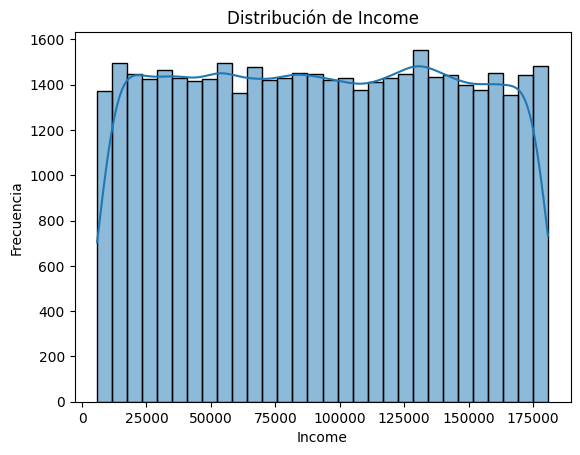


Estadísticas de Income:
count     43000.000000
mean      93241.200070
std       50498.316182
min        5841.000000
25%       49610.000000
50%       93050.500000
75%      136744.500000
max      180802.000000
Name: Income, dtype: float64



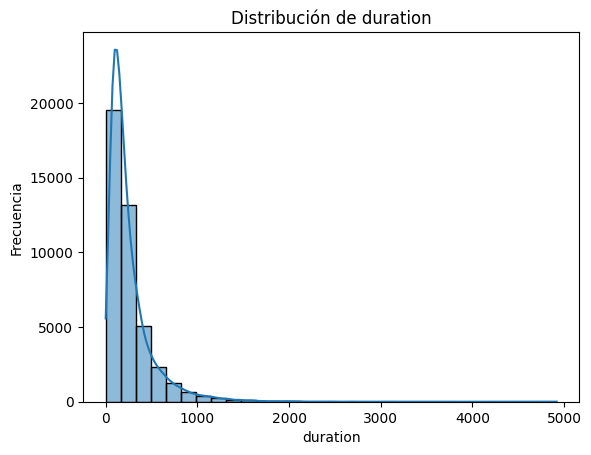


Estadísticas de duration:
count    43000.000000
mean       257.739279
std        258.666033
min          0.000000
25%        102.000000
50%        179.000000
75%        319.000000
max       4918.000000
Name: duration, dtype: float64



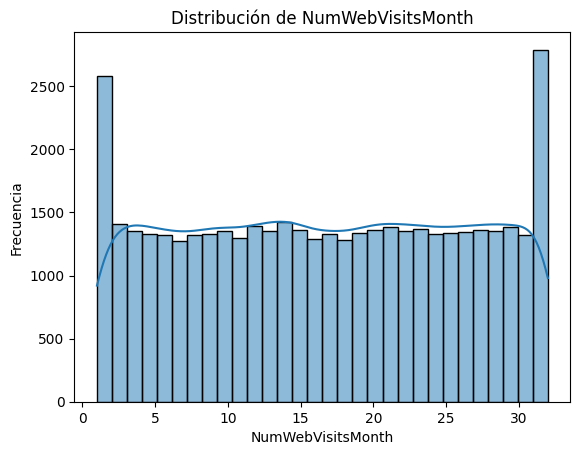


Estadísticas de NumWebVisitsMonth:
count    43000.000000
mean        16.589698
std          9.239205
min          1.000000
25%          9.000000
50%         17.000000
75%         25.000000
max         32.000000
Name: NumWebVisitsMonth, dtype: float64



In [ ]:
        # 2. Distribución de variables numéricas
numericas = ['age', 'Income', 'duration', 'NumWebVisitsMonth']

for col in numericas:
    plt.figure()
    sns.histplot(data=merged_df, x=col, kde=True, bins=30)
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()

    print(f"\nEstadísticas de {col}:\n{merged_df[col].describe()}\n")

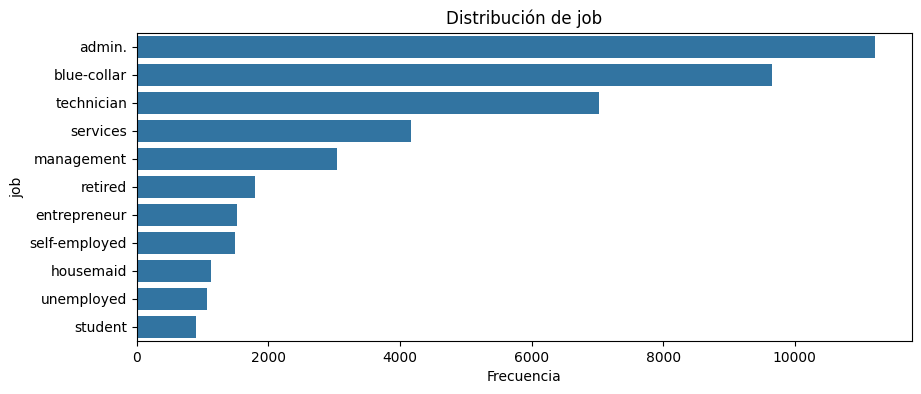


Distribución porcentual de job:

job
admin.           26.088372
blue-collar      22.451163
technician       16.339535
services          9.679070
management        7.093023
retired           4.162791
entrepreneur      3.539535
self-employed     3.462791
housemaid         2.611628
unemployed        2.472093
student           2.100000
Name: proportion, dtype: float64

------------------------------------------------------------


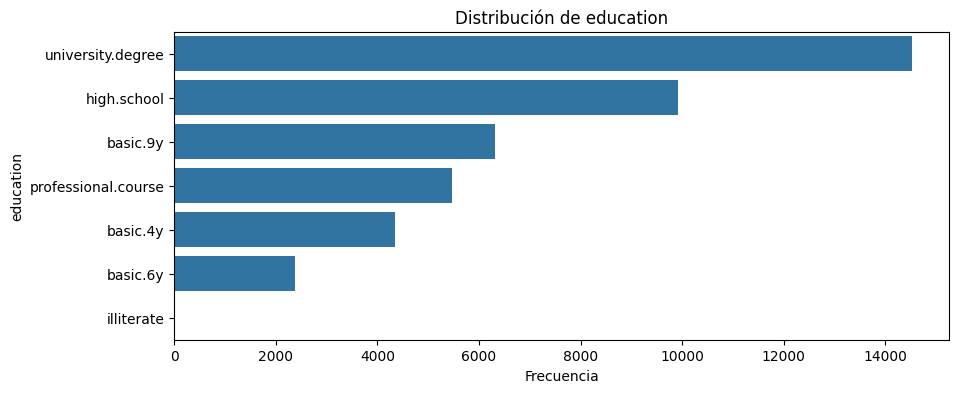


Distribución porcentual de education:

education
university.degree      33.788372
high.school            23.081395
basic.9y               14.672093
professional.course    12.737209
basic.4y               10.130233
basic.6y                5.548837
illiterate              0.041860
Name: proportion, dtype: float64

------------------------------------------------------------


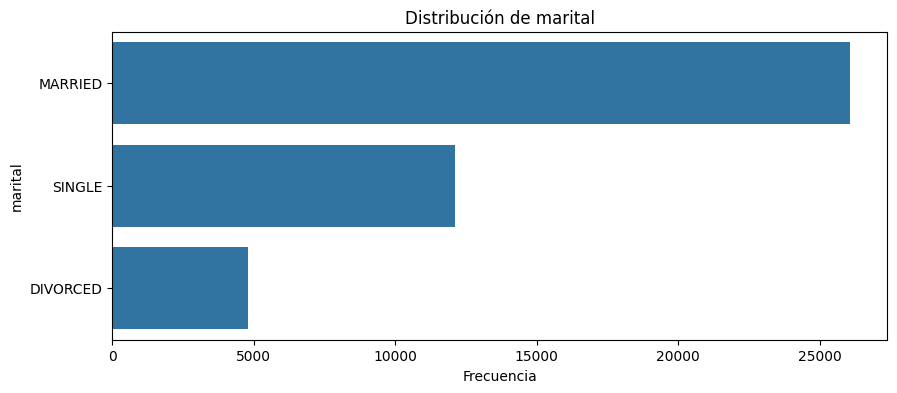


Distribución porcentual de marital:

marital
MARRIED     60.660465
SINGLE      28.151163
DIVORCED    11.188372
Name: proportion, dtype: float64

------------------------------------------------------------


In [ ]:
        # 3. Distribución de variables categóricas

categoricas = ['job', 'education', 'marital']

for col in categoricas:
    plt.figure(figsize=(10, 4))
    sns.countplot(data=merged_df, y=col, order=merged_df[col].value_counts().index)
    plt.title(f'Distribución de {col}')
    plt.xlabel('Frecuencia')
    plt.ylabel(col)
    plt.show()

    print(f"\nDistribución porcentual de {col}:\n")
    print(merged_df[col].value_counts(normalize=True) * 100)
    print("\n" + "-"*60)

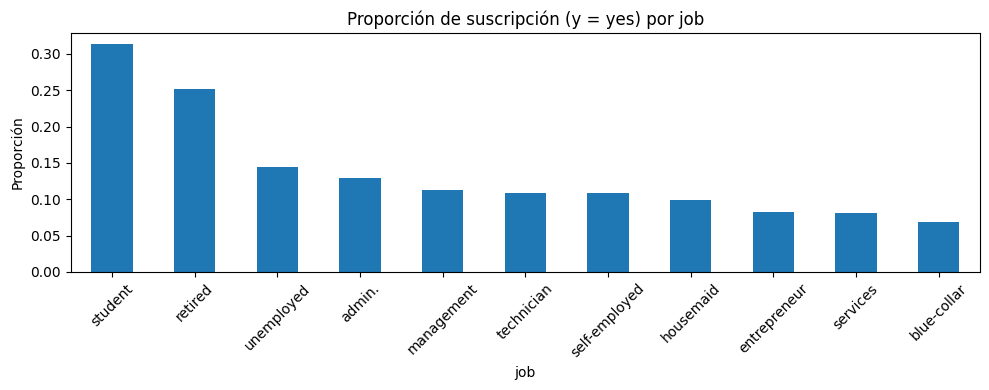

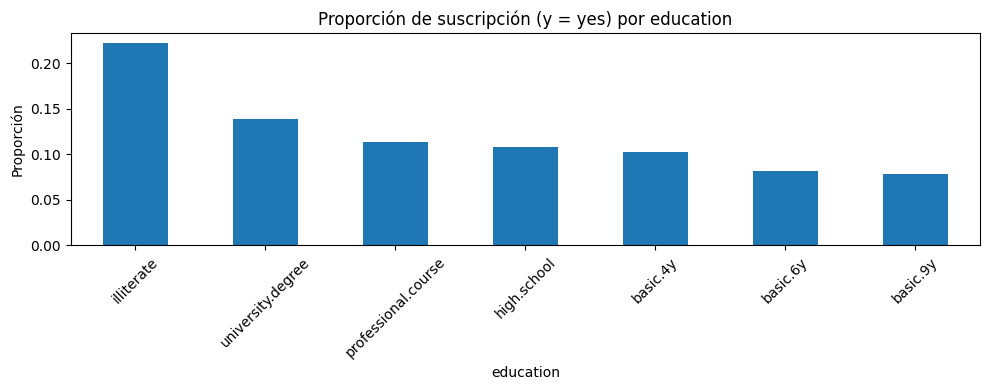

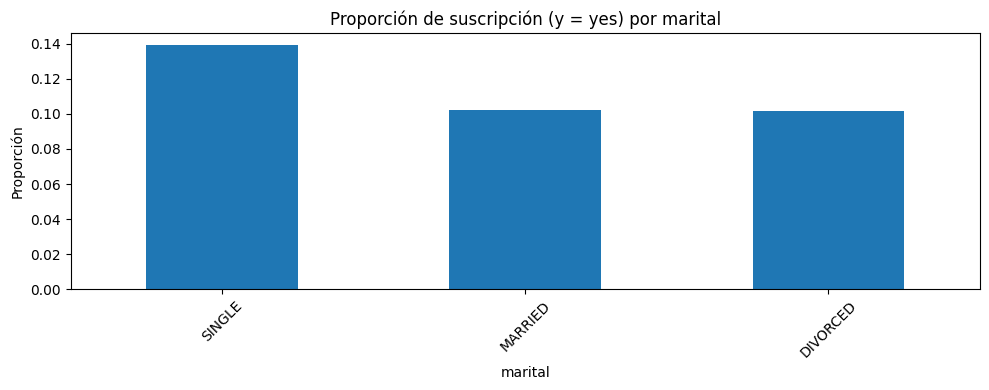

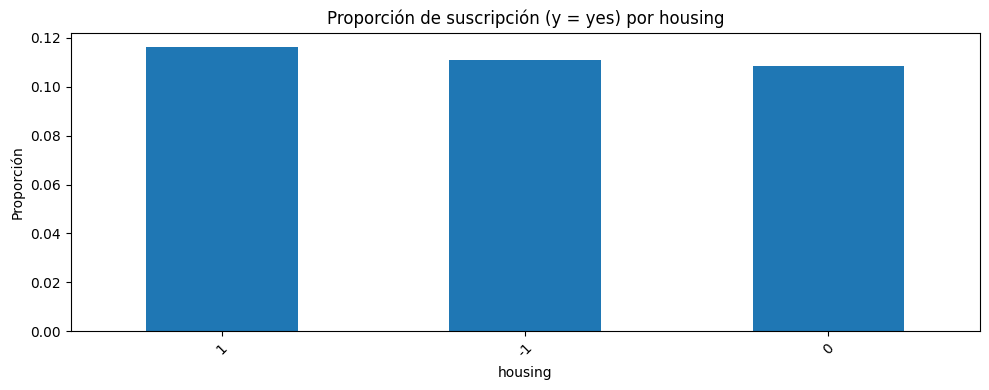

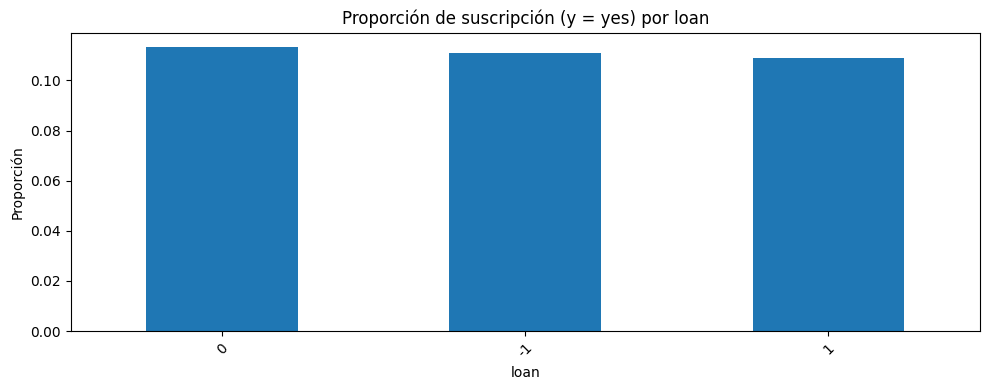

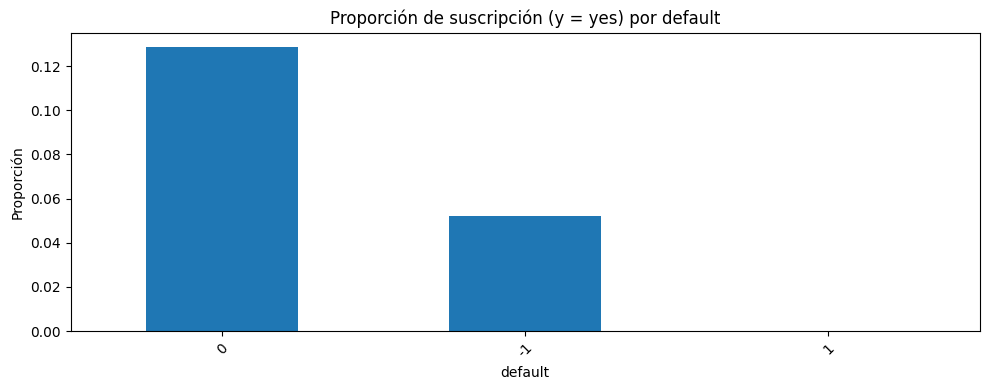

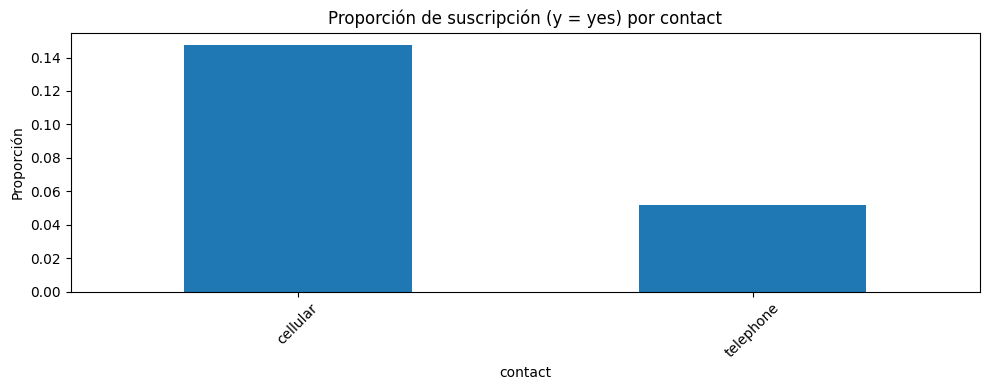

In [33]:
# 2.3 EDA: Análisis Bivariado con respecto a y

# Variables categóricas vs. y 
# Vamos a ver cómo cambia la proporción de y = "yes" según: job, education, marital, housing, loan, default o contact

import seaborn as sns
import matplotlib.pyplot as plt

cat_cols = ['job', 'education', 'marital', 'housing', 'loan', 'default', 'contact']

for col in cat_cols:
    plt.figure(figsize=(10, 4))
    prop = merged_df.groupby(col)['y'].value_counts(normalize=True).unstack().fillna(0)
    prop['yes'].sort_values(ascending=False).plot(kind='bar')
    plt.title(f'Proporción de suscripción (y = yes) por {col}')
    plt.ylabel('Proporción')
    plt.xlabel(col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

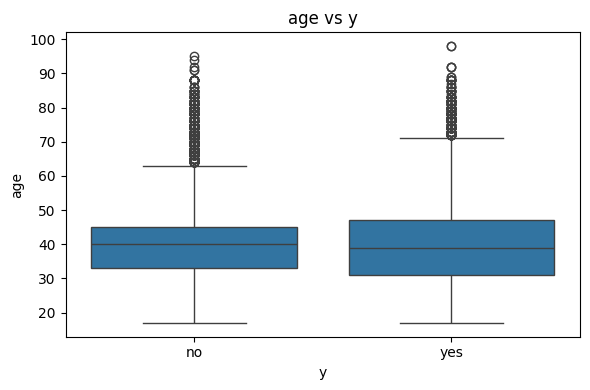

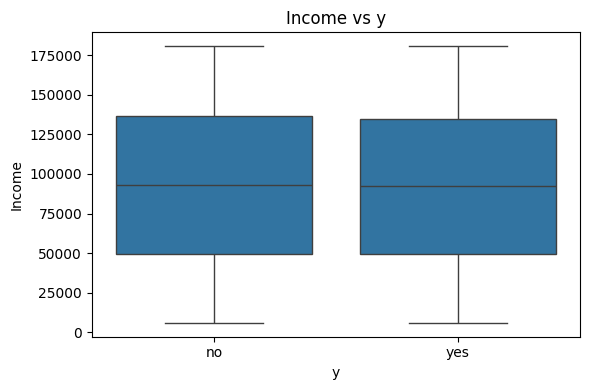

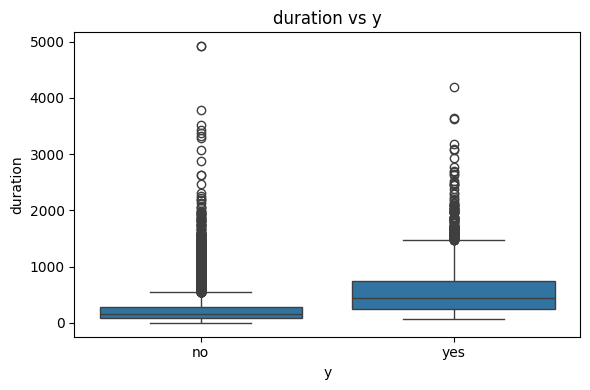

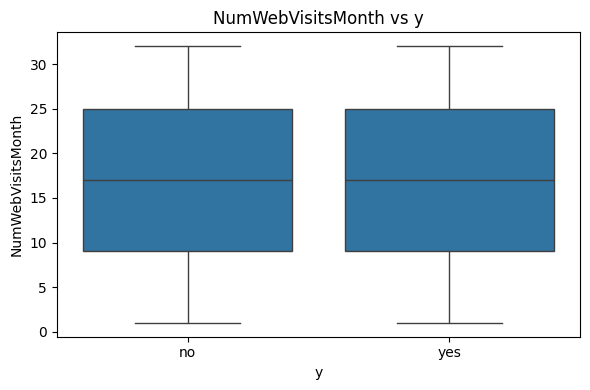

In [36]:
# Variables numéricas vs. y 
# Vamos a comparar la media o distribución de age, Income, duration, NumWebVisitsMonth según y = "yes" o "no". Para esto, usaremos boxplots.

num_cols = ['age', 'Income', 'duration', 'NumWebVisitsMonth']

for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=merged_df, x='y', y=col)
    plt.title(f'{col} vs y')
    plt.ylabel(col)
    plt.xlabel('y')
    plt.tight_layout()
    plt.show()

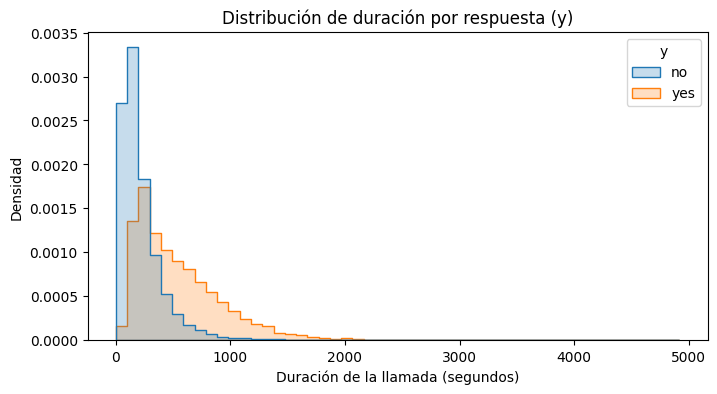

In [ ]:
# Relación duración de llamada vs. conversión.
# La Duración suele ser muy predictiva. Lo visulizamos mejor con un histograma de duration por valor de y:
 
plt.figure(figsize=(8, 4))
sns.histplot(data=merged_df, x='duration', hue='y', element='step', stat='density', common_norm=False, bins=50)
plt.title('Distribución de duración por respuesta (y)')
plt.xlabel('Duración de la llamada (segundos)')
plt.ylabel('Densidad')
plt.show()


In [39]:
#2.4 EDA: Resumen de hallazgos clave y próximos pasos

eda_notes = """
#2.4 Hallazgos clave
duration vs. y: Los Clientes con llamadas más largas tienen mayor probabilidad de suscribir.
Este patrón es fuerte porque duration está relacionada con el interés/conversación.

job vs. y: Algunas profesiones como admin., technician y retired suelen tener tasas de suscripción más altas.
Otras como blue-collar tienden a tener tasas más bajas.

education vs. y: Personas con mayor nivel educativo (university.degree) tienen mayor propensión a suscribir.
El grupo illiterate suele tener tasa baja, pero también puede ser pequeño en volumen.

marital vs. y: Solteros tienden a suscribir más que casados, aunque depende del resto del perfil.

housing, loan, default vs. y: Clientes sin hipoteca (housing = 0) o sin préstamos (loan = 0) tienden a suscribir más.
default = 1 suele estar asociado a baja conversión, aunque hay muchos -1 (desconocido).

age vs. y: Mayores de 50 años pueden tener tasas más altas.
No obstante, el patrón puede ser no lineal: no necesariamente aumenta con la edad.

Income vs. y: Clientes con ingresos medios-altos pueden tener más probabilidad de suscribir, pero el efecto puede ser más débil que otras variables como duration.
"""
print(eda_notes)


#2.4 Hallazgos clave
duration vs. y: Los Clientes con llamadas más largas tienen mayor probabilidad de suscribir.
Este patrón es fuerte porque duration está relacionada con el interés/conversación.

job vs. y: Algunas profesiones como admin., technician y retired suelen tener tasas de suscripción más altas.
Otras como blue-collar tienden a tener tasas más bajas.

education vs. y: Personas con mayor nivel educativo (university.degree) tienen mayor propensión a suscribir.
El grupo illiterate suele tener tasa baja, pero también puede ser pequeño en volumen.

marital vs. y: Solteros tienden a suscribir más que casados, aunque depende del resto del perfil.

housing, loan, default vs. y: Clientes sin hipoteca (housing = 0) o sin préstamos (loan = 0) tienden a suscribir más.
default = 1 suele estar asociado a baja conversión, aunque hay muchos -1 (desconocido).

age vs. y: Mayores de 50 años pueden tener tasas más altas.
No obstante, el patrón puede ser no lineal: no necesariamente aumenta c